<a href="https://colab.research.google.com/github/ulya1202/NLP/blob/main/NER_Azerbaijiani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NER

##Import

### Import libraries

In [ ]:
from sklearn.metrics import confusion_matrix

In [1]:
# PyTorch-dan AdamW optimizatorunu import edirik
from torch.optim import AdamW
from transformers import get_scheduler

In [2]:
from torch.utils.data import Dataset, DataLoader

In [3]:
#NEGoogle Colab-da saxlanılan gizli açarları (tokenləri) əldə etmək üçün istifadə olunur.
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')
WB_TOKEN = userdata.get('wb')


In [4]:
!pip install wandb==0.15.12 evaluate seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 25.5 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=77879bedcb0f6b6b6b89fd153a2207228274465931093941cd10a2748cb80346
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
  Created wheel for pathtools: filename=pathtools-0.1.2-py3-none-any.whl size=8792 sha256=196781d67ad6a0345cd26a3fce951dccd100427cbc22621f4ecdb18c8d1e5e5c
  Stored in directory: /root/.cache/pip/wheels/ea/b7/8b/84e94095ea418b9442f5abeba4ca7b0ad52d3fe7b69d6238a6
Successfully built seqeval pathtools
  Attempting uninstall: protobuf
    Found e

In [5]:
# #NER: Kitabxanaların spesifik versiyalarını quraşdıraraq mühitin stabilliyini təmin edirik. Bəzən fərqli versiyalar arasında uyğunsuzluqlar yarana bilər.
# # !pip install numpy==1.26.4 --force-reinstall
# # !pip uninstall wandb -y
# # !pip cache purge
# #NER: Layihə üçün lazımi Python kitabxanalarını quraşdırırıq.
# # Müəyyən versiyaları təyin etmək, kodun fərqli mühitlərdə eyni cür işləməsini təmin edir (reproducibility).


In [6]:
#Data analizi (pandas), riyazi hesablamalar (numpy) və vizuallaşdırma (matplotlib, seaborn) üçün standart kitabxanalar.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
from collections import defaultdict, Counter

In [8]:
from datasets import load_dataset

In [9]:
import torch
from tqdm import tqdm
from accelerate import Accelerator
import evaluate

In [10]:
import torch.nn
import transformers

In [11]:
from transformers import AutoTokenizer,AutoModelForTokenClassification,DataCollatorForTokenClassification

In [12]:

from seqeval.metrics import classification_report, f1_score, accuracy_score, precision_score, recall_score



###Import Dataset

In [13]:
raw_dataset = load_dataset("wikiann", "az")

README.md: 0.00B [00:00, ?B/s]

az/validation-00000-of-00001.parquet:   0%|          | 0.00/81.3k [00:00<?, ?B/s]

az/test-00000-of-00001.parquet:   0%|          | 0.00/80.6k [00:00<?, ?B/s]

az/train-00000-of-00001.parquet:   0%|          | 0.00/769k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

## Preprocess

In [14]:
dataset = raw_dataset.remove_columns(['langs']) #sonra spansida ederik

In [15]:
dataset

DatasetDict({
    validation: Dataset({
        features: ['tokens', 'ner_tags', 'spans'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['tokens', 'ner_tags', 'spans'],
        num_rows: 1000
    })
    train: Dataset({
        features: ['tokens', 'ner_tags', 'spans'],
        num_rows: 10000
    })
})

## Main variables

In [16]:
ner_feature = dataset["train"].features["ner_tags"]

In [17]:
#NER: Datasetdəki NER etiketlərinin (tag) adlarını bir siyahıya yığırıq (məsələn, 'B-PER', 'I-LOC'). Bu, rəqəmsal etiketləri mənalı adlara çevirmək üçün lazım olacaq.
label_names = dataset['train'].features['ner_tags'].feature.names

#NER: Fine-tuning (incə tənzimləmə) üçün istifadə edəcəyimiz əvvəlcədən öyrədilmiş modelin adını təyin edirik. "xlm-roberta-base" çoxdilli mətnlər üçün güclü bir seçimdir.
model_name = "xlm-roberta-base"

In [18]:
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

In [19]:
old_colum_names=dataset['train'].column_names

In [53]:
accelerator=Accelerator()

In [20]:
num_epochs=3
batch_size=16
lr=3e-5
weight_decay=0.01

## Functions

###EDA Functions

In [21]:
#NER: Bu funksiya, mətndəki hər bir sözün istifadə tezliyini sayır və ən çox istifadə olunanları vizuallaşdırır. Bu, datadakı ümumi söz paylanmasını anlamağa kömək edir.
def count_freq_of_words(column_with_words, top_n=50):
    # Bütün tokenləri tək bir siyahıya yığırıq
    all_tokens = [word for row in column_with_words for word in row]
    # Counter ilə hər bir sözün sayını anında hesablayırıq
    word_counts = Counter(all_tokens)

    # Ən çox rast gəlinən `top_n` sözü seçirik
    top_words = word_counts.most_common(top_n)
    top_words_df = pd.DataFrame(top_words, columns=['word', 'count'])

    plt.figure(figsize=(12, 6))
    sns.barplot(x='word', y='count', data=top_words_df)
    plt.xticks(rotation=90)
    plt.title(f'Top {top_n} Most Frequent Words')
    plt.show()
    return top_words_df



In [22]:
#NER: Bu funksiya, hər bir NER etiketinin (məsələn, 'B-LOC', 'O') datada neçə dəfə göründüyünü sayır. Bu, etiketlər arasındakı balansı (imbalance) yoxlamaq üçün vacibdir.
def ner_tag_counts(ner_tag_column, tag_names):
    # Bütün etiket nömrələrini tək bir siyahıya yığırıq
    all_tags = [tag for tags in ner_tag_column for tag in tags]
    # Hər bir etiket nömrəsinin sayını hesablayırıq
    tag_counts = Counter(all_tags)

    # Etiket nömrələrini adları ilə əvəz edirik
    ner_tag_counts_with_names = {tag_names[key]: value for key, value in tag_counts.items()}
    ner_tag_counts_df = pd.DataFrame(list(ner_tag_counts_with_names.items()), columns=['tag', 'count'])
    ner_tag_counts_df = ner_tag_counts_df.sort_values(by='count', ascending=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(x='tag', y='count', data=ner_tag_counts_df)
    plt.xticks(rotation=90)
    plt.title('NER Tag Counts')
    plt.show()
    return ner_tag_counts_df

In [23]:
def plot_top_tokens_by_tag(df, label_names, top_n=10, figsize=(12, 6), dark=False):
    # menim secdiyim rengler
    custom_palette = ["#FFA726",  # Narıncı
                      "#81C784",  # Yaşıl
                      "#64B5F6",  # Göy
                      "#BA68C8",  # Bənövşəyi
                      "#F06292"]  # Çəhrayı

    # Tema
    if dark:
        sns.set_theme(style="darkgrid")
        plt.style.use("dark_background")
    else:
        sns.set_theme(style="whitegrid")

    token_tag_counter = defaultdict(Counter)

    # Token və tag sayğacı
    for tokens, tags in zip(df['tokens'], df['ner_tags']):
        for token, tag_id in zip(tokens, tags):
            tag_name = label_names[tag_id]
            main_tag = tag_name.split("-")[-1] if "-" in tag_name else tag_name
            token_tag_counter[token][main_tag] += 1

    # Token → (ən məşhur tag, say)
    di = {}
    for token, tag_counter in token_tag_counter.items():
        most_common_tag, count = tag_counter.most_common(1)[0]
        di[token] = (most_common_tag, count)

    # Tag → tokenlər
    tag_token_map = defaultdict(list)
    for token, (tag, count) in di.items():
        tag_token_map[tag].append((token, count))

    # Vizual üçün məlumat yığımı
    plot_data = []
    for tag, token_counts in tag_token_map.items():
        top_tokens = sorted(token_counts, key=lambda x: x[1], reverse=True)[:top_n]
        for token, count in top_tokens:
            plot_data.append({"tag": tag, "token": token, "count": count})

    df_plot = pd.DataFrame(plot_data)

    # Plot
    plt.figure(figsize=figsize)
    sns.barplot(
        data=df_plot,
        x="token",
        y="count",
        hue="tag",
        palette=custom_palette[:len(df_plot['tag'].unique())],  # rəng sayı uyğunlaşdırılır
        edgecolor=None  # Qara çərçivə olmur
    )

    plt.title(f"Hər NER Tag üçün Ən Məşhur {top_n} Token", fontsize=14)
    plt.xlabel("Token", fontsize=12)
    plt.ylabel("İstifadə Sayı", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.legend(title="NER Tag", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.show()

    return di


### other function

In [ ]:
def analyze_and_show_errors(model, dataloader, accelerator, tokenizer, label_list):


    model.eval()

    all_true_labels = []
    all_predictions = []
    error_examples = [] # Səhvləri toplamaq üçün yeni siyahı

    for batch in tqdm(dataloader, desc="Səhv analizi üçün hesablanır"):
        with torch.no_grad():
            outputs = model(**batch)

        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)
        true_labels = batch["labels"]
        input_ids = batch["input_ids"]

        # Nəticələri bütün GPU-lardan toplamaq
        predictions_gathered = accelerator.gather_for_metrics(predictions).cpu().numpy()
        true_labels_gathered = accelerator.gather_for_metrics(true_labels).cpu().numpy()
        input_ids_gathered = accelerator.gather_for_metrics(input_ids).cpu().numpy()

        for i in range(len(input_ids_gathered)):
            preds = predictions_gathered[i]
            labels = true_labels_gathered[i]
            ids = input_ids_gathered[i]
            has_error = False
            full_tokens = tokenizer.convert_ids_to_tokens(ids)
            true_seq = []
            pred_seq = []

            for p, l, token in zip(preds, labels, full_tokens):
                if l != -100: # Padding və subwordları nəzərə almırıq
                    all_predictions.append(p)
                    all_true_labels.append(l)
                    if p != l:
                        has_error = True

                    true_seq.append(label_list[l])
                    pred_seq.append(label_list[p])

            if has_error:
                clean_tokens = tokenizer.convert_ids_to_tokens(ids, skip_special_tokens=True)
                full_text = tokenizer.decode(ids, skip_special_tokens=True)

                error_examples.append({
                    "text": full_text,
                    "tokens": clean_tokens,
                    "true_labels": [label for label in true_seq if label != 'O'],
                    "predicted_labels": [label for label in pred_seq if label != 'O'],
                    "full_true_sequence": true_seq,
                    "full_predicted_sequence": pred_seq
                })

    cm = confusion_matrix(y_true=all_true_labels, y_pred=all_predictions, labels=np.arange(len(label_list)))
    plt.figure(figsize=(15, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_list, yticklabels=label_list)
    plt.title('Confusion Matrix', fontsize=16)
    plt.ylabel('Doğru Etiket', fontsize=12)
    plt.xlabel('Təxmin Edilmiş Etiket', fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return error_examples

##EDA

### Check dataset

In [24]:
#NER: Datanın quruluşunu anlamaq üçün ilk nümunəyə baxırıq. Bu, hansı sütunların olduğunu ('tokens', 'ner_tags' və s.) göstərir.
print(dataset["train"][0])
print(dataset['train'].features)

{'tokens': ['Lakin', 'üsyana', 'qoşulmuş', 'zadəganlar', 'xəyanət', 'etdilər', ',', 'üsyançılar', 'döyüşdə', 'məğlub', 'oldular', 'və', 'Moskvadan', 'Kaluqaya', 'çəkildilər', '.'], 'ner_tags': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 5, 5, 0, 0], 'spans': ['LOC: Moskvadan', 'LOC: Kaluqaya']}
{'tokens': List(Value('string')), 'ner_tags': List(ClassLabel(names=['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC'])), 'spans': List(Value('string'))}


In [25]:
#NER: Datanı daha rahat analiz etmək üçün onu pandas DataFrame formatına çeviririk.
dataset.set_format(type='pandas')
df = dataset['train'][:]

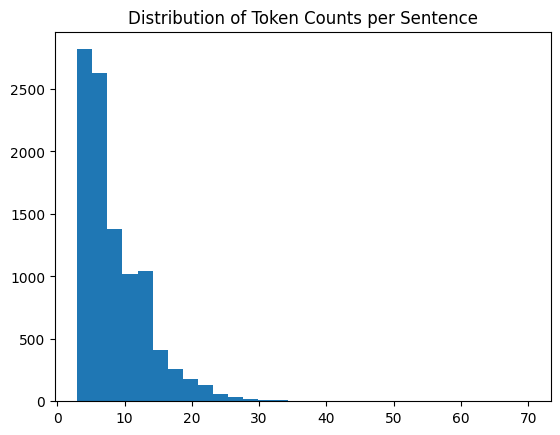

count    10000.000000
mean         8.598700
std          4.748064
min          3.000000
25%          5.000000
50%          7.000000
75%         11.000000
max         70.000000
Name: tokens, dtype: float64


In [26]:
#NER: Hər bir cümlədəki token sayının paylanmasını göstərən bir histogram qururuq. Bu, model üçün maksimum uzunluq (`max_length`) seçməyə kömək edir.
token_count = df['tokens'].apply(len)
plt.hist(token_count, bins=30)
plt.title('Distribution of Token Counts per Sentence')
plt.show()
print(token_count.describe())

In [27]:
#NER: Datanın keyfiyyətini yoxlamaq üçün təkrarlanan (duplicate) sətirlərin olub-olmadığını yoxlayırıq.
print(f"Təkrarlanan sətirlərin sayı: {df['tokens'].duplicated().sum()}")

Təkrarlanan sətirlərin sayı: 0


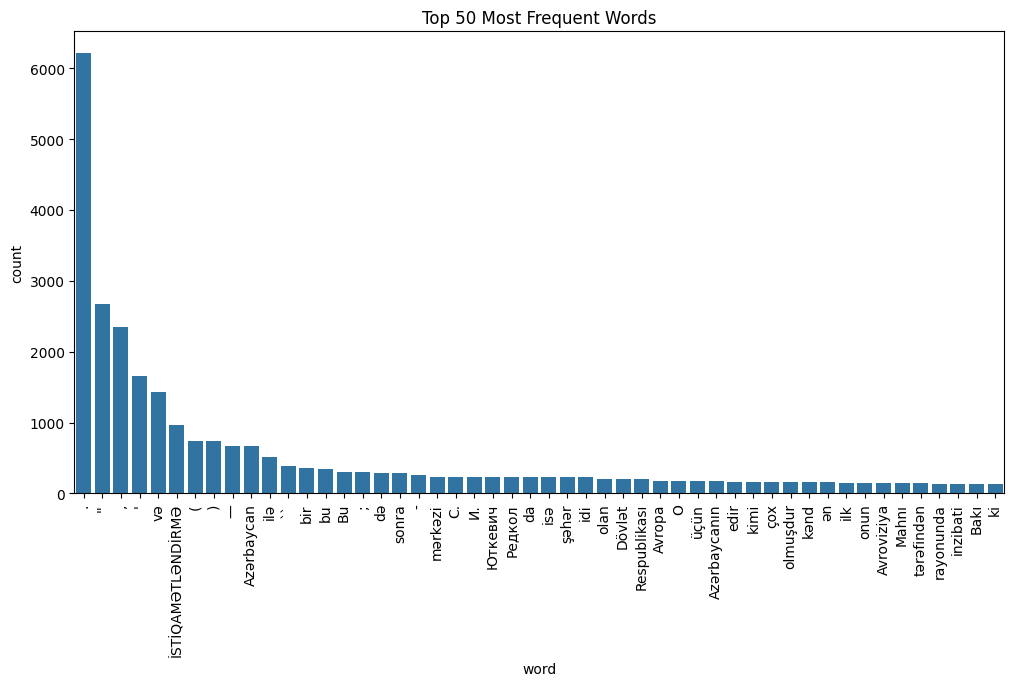

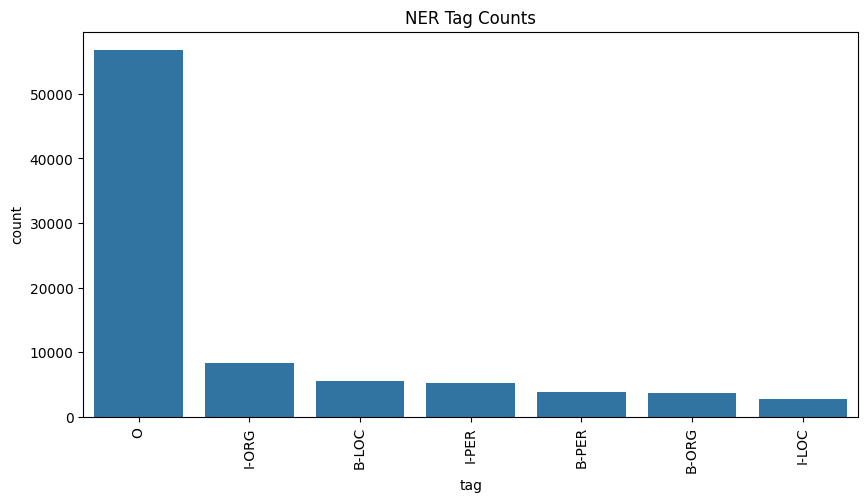

In [28]:
#NER: Yuxarıda təyin etdiyimiz funksiyaları çağıraraq ən çox istifadə olunan sözləri və NER etiketlərinin sayını vizuallaşdırırıq.
top_words = count_freq_of_words(df['tokens'], 50)
ner_tag_count = ner_tag_counts(df['ner_tags'], label_names)

In [29]:
ner_tag_count

,tag,count
0,O,56825
4,I-ORG,8269
1,B-LOC,5500
6,I-PER,5229
5,B-PER,3789
3,B-ORG,3636
2,I-LOC,2739


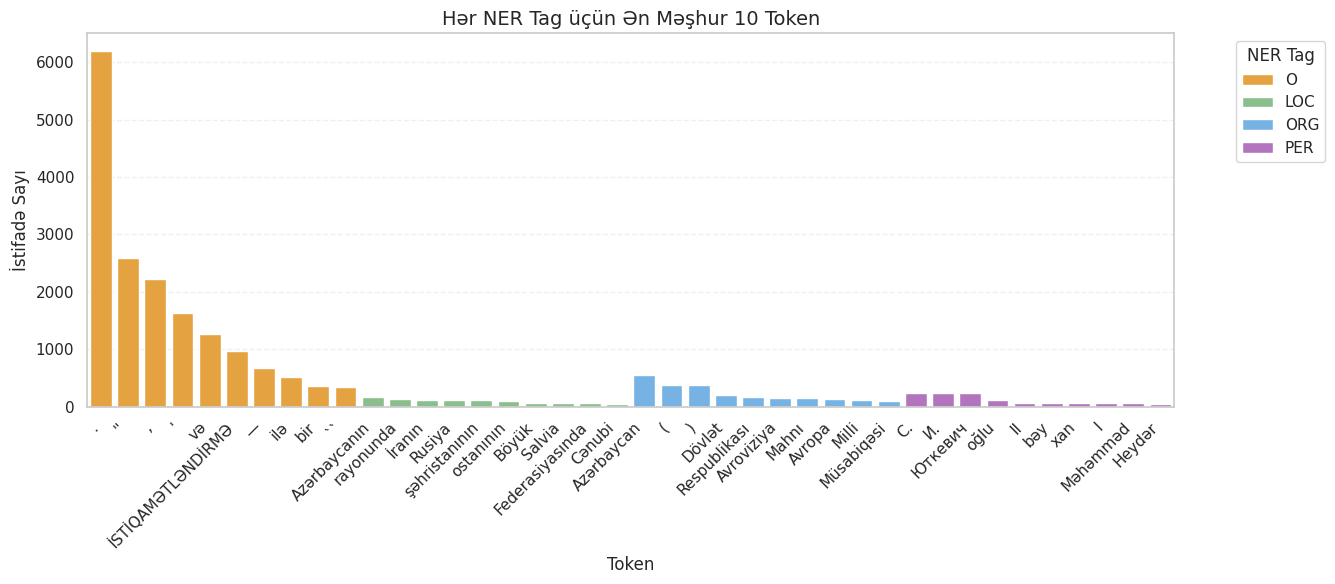

In [30]:
word_tag_count_pairs=plot_top_tokens_by_tag(df, label_names, top_n=10, dark=False)

In [31]:
dataset.reset_format()

## Tokenization /Aligning with labels/Padding

In [37]:
 # və ya "Davlan/xlm-roberta-base-ner-hrl"
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [38]:
#First problem aligning problem of tokens.
#so we need to align in a way that new target will display the begining another pat of word will be -100

### 1. Lets solve first problem (aligning of NER)

####optional: on sample example

In [ ]:
#we have word_ids method in tokenizer that will help in this problem

In [ ]:
sample_tokens=dataset['train'][0]['tokens']
sample_tokens_tag=dataset['train'][0]['ner_tags']
sample_tokenized=tokenizer(sample_tokens, is_split_into_words=True)

In [ ]:
print(sample_tokenized.word_ids()) #this shows us , word ids , which token is for which token
print(sample_tokenized.tokens())

[None, 0, 1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 6, 6, 7, 7, 7, 7, 8, 8, 9, 10, 10, 11, 12, 12, 13, 13, 13, 14, 14, 14, 15, 15, None]
['<s>', '▁Lakin', '▁', 'üs', 'yana', '▁qoşul', 'muş', '▁', 'zadə', 'gan', 'lar', '▁x', 'ə', 'yan', 'ət', '▁et', 'dilər', '▁', ',', '▁', 'üs', 'yan', 'çılar', '▁döyüş', 'də', '▁məğlub', '▁oldu', 'lar', '▁və', '▁Moskva', 'dan', '▁Ka', 'luq', 'aya', '▁çəki', 'l', 'dilər', '▁', '.', '</s>']


In [ ]:

pd.set_option('display.max_columns', None)
df_sample = pd.DataFrame({
    'token': sample_tokenized.tokens(),
    'word_id': sample_tokenized.word_ids(),

}).T
display(df_sample)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39
token,<s>,▁Lakin,▁,üs,yana,▁qoşul,muş,▁,zadə,gan,lar,▁x,ə,yan,ət,▁et,dilər,▁,",",▁,üs,yan,çılar,▁döyüş,də,▁məğlub,▁oldu,lar,▁və,▁Moskva,dan,▁Ka,luq,aya,▁çəki,l,dilər,▁,.,</s>
word_id,NaN,0.0,1.0,1.0,1.0,2.0,2.0,3.0,3.0,3.0,3.0,4.0,4.0,4.0,4.0,5.0,5.0,6.0,6.0,7.0,7.0,7.0,7.0,8.0,8.0,9.0,10.0,10.0,11.0,12.0,12.0,13.0,13.0,13.0,14.0,14.0,14.0,15.0,15.0,NaN


#### Lets implement aligning function

In [39]:
#Label tutalim beledi
#bu bizde labeller [0,...]
#eger word ids bizde None dirse gel tagi olsun -100
#sonra gelir normal soze , ve bashlanqici geldiyi uchun onun idsini yaziriq meseln 0
#getdik eger wor ids evvelki word ids beraberdirse , -100  qoyuruq
#getdik eger word idsi evvekine beraber deyilse , heqiqi idsini elave edirk , ve prev kimii bu word idini qoyuruq
#nece teyin edirik ... bu word _ids ele bizde taglardaki idx ni tapa bilerik
 #BU yazdiqimiz base versiyadi , amm tebii ki , bashqa cur de etmek olar,TUTALIM  eger -100 u -> I-Per ile   evez etmek  bu cur format BLOU uchun de uygun olardi , geli heleki saade versiya il gedek

In [40]:
def tokenize_and_align_labels(examples):
    tokenized_inputs = tokenizer(examples["tokens"], truncation=True, is_split_into_words=True)
    labels = []
    for i, label_sequence in enumerate(examples["ner_tags"]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        previous_word_idx = None
        label_ids = []
        for word_idx in word_ids:
            if word_idx is None or word_idx == previous_word_idx:
                label_ids.append(-100)
            else:
                label_ids.append(label_sequence[word_idx])
            previous_word_idx = word_idx
        labels.append(label_ids)
    tokenized_inputs["labels"] = labels
    return tokenized_inputs

In [41]:
# def align_labels_with_tokens(labels, word_ids):
#   new_tags=[]
#   prev_word_idx=None

#   for idx,word_idx in enumerate(word_ids):
#     if word_idx is None:
#       new_tags.append(-100)
#     elif word_idx!=prev_word_idx:
#       new_tags.append(labels[word_idx])
#     else:
#       new_tags.append(-100)
#     prev_word_idx=word_idx
#   return new_tags
# def tokenize_and_align(example):
#   ex_tags=example['ner_tags']
#   tokens=tokenizer(example['tokens'],truncation=True, is_split_into_words=True)

#   word_ids=tokens.word_ids()
#   new_tags=align_labels_with_tokens(ex_tags,word_ids)

#   tokens.update({'labels':new_tags})
#   return tokens


In [42]:
new_dataset=dataset.map(tokenize_and_align_labels, batched=True, remove_columns=old_colum_names)
# new_dataset = new_dataset.remove_columns(['tokens', 'word_ids', 'spans', 'ner_tags'])

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

####optional: implement this function on sample that we mentioned at the top

In [ ]:
print(sample_tokens_tag) #5--> Begining of Locations


In [ ]:
new_dataset['train']

In [ ]:
new_tags=align_labels_with_tokens(sample_tokens_tag,sample_tokenized.word_ids())
df_sample = pd.DataFrame({
    'token': sample_tokenized.tokens(),
    'word_id': sample_tokenized.word_ids(),
    'new_tag':new_tags
}).T

df_sample

### 2. Lets solve second problem : (padding with Data Collator)

In [43]:
collator=DataCollatorForTokenClassification(tokenizer=tokenizer)

####optional: example

In [ ]:
tokenizer.vocab['<pad>']

In [ ]:
batch_label_padded=collator([new_dataset['train'][0], new_dataset['train'][1]])['labels']

In [ ]:
print(f"first_example length:{len(new_dataset['train'][0]['labels'])}\nsecond_example length:{len(new_dataset['train'][1]['labels'])}")


In [ ]:
flattened_labels = [example.flatten().tolist() for example in batch_label_padded]
df_padded_labels = pd.DataFrame(flattened_labels)
df_padded_labels

## EVAL metrices

In [32]:
metric=evaluate.load('seqeval')

####optional: compute on example

In [ ]:
label_names=dataset['train'].features['ner_tags'].feature.names

In [ ]:
print(f"example of our new labels , this labels represents indexes of ners:{new_dataset['train'][0]['labels']}")

NameError: name 'new_dataset' is not defined

In [ ]:
ners=[label_names[idx] for idx in new_dataset['train'][0]['labels'] if idx!=-100]

In [ ]:
changed_ner=ners.copy()

In [ ]:
changed_ner[0]='B-LOC'

In [ ]:
metric.compute(predictions=[changed_ner], references=[ners])

### compute metrices function

In [33]:
def compute_metrics(eval_preds):
    logits, labels = eval_preds
    pred_labels = np.argmax(logits, axis=-1)

    # True label və prediction-ları -100-ləri nəzərə almadan yığırıq
    true_labels = [[label_names[l] for l in label if l != -100] for label in labels]
    predicted_labels = [
        [label_names[p] for p, l in zip(prediction, label) if l != -100]
        for prediction, label in zip(pred_labels, labels)
    ]

    results = metric.compute(predictions=predicted_labels, references=true_labels)

    return {
        'precision': results['overall_precision'],
        'recall': results['overall_recall'],
        'f1': results['overall_f1'],
        'accuracy': results['overall_accuracy'],
    }


##Model

In [34]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name, num_labels=len(label_names), id2label=id2label, label2id=label2id
)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## Training with transformers lib.

In [ ]:
!pip install --upgrade transformers datasets evaluate numpy
from transformers import AutoModelForTokenClassification, AutoTokenizer, TrainingArguments, Trainer
from datasets import load_dataset
import numpy as np

In [ ]:
#NER: `wandb` və `huggingface_hub` hesablarına daxil oluruq.
import wandb
from huggingface_hub import login
wandb.login(key=WB_TOKEN)
login(token=HF_TOKEN)

In [ ]:
args=TrainingArguments(
    'bert-finetuned-ner',
    eval_strategy='epoch', #evalute nece defeden bir versin
    save_strategy='epoch',

    learning_rate=lr,
    num_train_epochs=num_epochs,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    weight_decay=0.01,
    push_to_hub=True
)

In [ ]:
trainer=Trainer(
    model=model,
    args=args,
    train_dataset=new_dataset['train'],
    eval_dataset=new_dataset['validation'],

    data_collator=collator,
    compute_metrics=compute_metrics,
    tokenizer=tokenizer
)

In [ ]:
trainer.train()

In [ ]:
trainer.evaluate()

## Optional: Custom Loop

In [35]:
class Train_NER:
    def __init__(self, model, num_training_epochs, label_list, metric, train_loader=None, test_loader=None, val_loader=None,
                 optimizer=None, lr_scheduler=None, accel=True, store_sample_losses=False):

        self.num_training_epochs = num_training_epochs
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.accel = accel
        self.model = model
        self.metric = metric
        self.label_list = label_list
        self.store_sample_losses = store_sample_losses
        self.sample_losses = []

        self.accelerator = Accelerator()
        print(f"Cihaz istifadə olunur: {self.accelerator.device}")
        self.dic = {'train_loss': [], 'val_loss': [], 'train_metrics': [], 'val_metrics': []}


        self.num_steps_each_epoch = len(self.train_loader) if self.train_loader else 0
        if self.num_steps_each_epoch == 0:
            print('XƏBƏRDARLIQ: train_loader təyin edilməyib!')

        self.total_stepsize = self.num_steps_each_epoch * self.num_training_epochs
        self.progress_bar = None

        if self.accel:
            self.model, self.optimizer, self.lr_scheduler, self.train_loader, self.val_loader, self.test_loader = \
                self.accelerator.prepare(
                    self.model, self.optimizer, self.lr_scheduler, self.train_loader, self.val_loader, self.test_loader
                )

    def train_one_epoch(self):
        self.model.train()
        total_loss = 0
        all_predictions = []
        all_labels = []

        for batch in self.train_loader:
            self.optimizer.zero_grad()
            outputs = self.model(**batch)
            loss = outputs.loss
            self.accelerator.backward(loss)
            self.optimizer.step()
            if self.lr_scheduler:
                self.lr_scheduler.step()

            total_loss += loss.item()
            if self.progress_bar:
                self.progress_bar.update(1)

            # Etiketləri (labels) və təxminləri (predictions) toplayırıq
            labels = batch["labels"]
            preds, true_labs = self._process_logits_and_labels(outputs.logits, labels)
            all_predictions.extend(preds)
            all_labels.extend(true_labs)

            if self.store_sample_losses:
                self._collect_sample_losses(batch, outputs)

        avg_loss = total_loss / len(self.train_loader)
        metrics = self.metric.compute(predictions=all_predictions, references=all_labels)

        result_metric = {
            'precision': metrics.get('overall_precision', 0.0),
            'recall': metrics.get('overall_recall', 0.0),
            'f1': metrics.get('overall_f1', 0.0),
            'accuracy': metrics.get('overall_accuracy', 0.0),
        }

        print(f"Train Loss: {avg_loss:.4f} | F1: {result_metric['f1']:.4f} | Accuracy: {result_metric['accuracy']:.4f}", end=' ')
        return avg_loss, result_metric

    def evaluate(self, eval_loader, split_name="val", collect_sample_losses=False):
        if not eval_loader:
            print(f'XƏBƏRDARLIQ: {split_name}_loader mövcud deyil.')
            return 0.0, {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'accuracy': 0.0}

        self.model.eval()
        total_loss = 0
        all_predictions = []
        all_labels = []

        if collect_sample_losses:
            self.sample_losses = []

        for batch in eval_loader:
            with torch.no_grad():
                outputs = self.model(**batch)

            loss = outputs.loss
            total_loss += loss.item()

            labels = batch["labels"]
            preds, true_labs = self._process_logits_and_labels(outputs.logits, labels)
            all_predictions.extend(preds)
            all_labels.extend(true_labs)

            if collect_sample_losses:
                self._collect_sample_losses(batch, outputs)

        avg_loss = total_loss / len(eval_loader)
        metrics = self.metric.compute(predictions=all_predictions, references=all_labels)

        result_metric = {
            'precision': metrics.get('overall_precision', 0.0),
            'recall': metrics.get('overall_recall', 0.0),
            'f1': metrics.get('overall_f1', 0.0),
            'accuracy': metrics.get('overall_accuracy', 0.0),
        }

        print(f"{split_name.capitalize()} Loss: {avg_loss:.4f} | F1: {result_metric['f1']:.4f} | Accuracy: {result_metric['accuracy']:.4f}")
        return avg_loss, result_metric

    def _process_logits_and_labels(self, logits, true_labels):
        predictions = logits.argmax(dim=-1)

        predictions_gathered = self.accelerator.gather_for_metrics(predictions)
        labels_gathered = self.accelerator.gather_for_metrics(true_labels)

        # -100 təmizləyirik və ID-ləri string-ə çeviririk
        true_predictions = [
            [self.label_list[p.item()] for (p, l) in zip(prediction, label) if l.item() != -100]
            for prediction, label in zip(predictions_gathered, labels_gathered)
        ]
        true_labels = [
            [self.label_list[l.item()] for (p, l) in zip(prediction, label) if l.item() != -100]
            for prediction, label in zip(predictions_gathered, labels_gathered)
        ]
        return true_predictions, true_labels

    def train(self):
        if self.total_stepsize == 0:
            print("Təlim başlaya bilmir, çünki train_loader boşdur və ya təyin edilməyib.")
            return None

        self.progress_bar = tqdm(range(self.total_stepsize))

        for epoch in range(self.num_training_epochs):
            print(f"\nEpoch {epoch + 1}/{self.num_training_epochs}", end=' | ')

            train_loss, train_metric = self.train_one_epoch()
            val_loss, val_metric = self.evaluate(self.val_loader, split_name="val")

            self.dic['train_loss'].append(train_loss)
            self.dic['val_loss'].append(val_loss)
            self.dic['train_metrics'].append(train_metric)
            self.dic['val_metrics'].append(val_metric)

        return self.dic

    def test(self, collect_sample_losses=False):
        return self.evaluate(self.test_loader, split_name="test", collect_sample_losses=collect_sample_losses)

    def history_plot(self):
        # F1 skoru üçün qrafik
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        train_f1 = [m['f1'] for m in self.dic['train_metrics']]
        val_f1 = [m['f1'] for m in self.dic['val_metrics']]
        plt.plot(train_f1, label='Train F1')
        plt.plot(val_f1, label='Val F1')
        plt.title("F1 Score History")
        plt.xlabel("Epoch")
        plt.ylabel("F1 Score")
        plt.legend()

        # Loss üçün qrafik
        plt.subplot(1, 2, 2)
        plt.plot(self.dic['train_loss'], label='Train Loss')
        plt.plot(self.dic['val_loss'], label='Val Loss')
        plt.title("Loss History")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()

        plt.tight_layout()
        plt.show()

    def save_model(self, path):
        # Accelerator-dan istifadə edərək modeli unwrapped edib yaddaşa veririk
        unwrapped_model = self.accelerator.unwrap_model(self.model)
        self.accelerator.save(unwrapped_model.state_dict(), path)
        print(f"Model yaddaşa verildi: {path}")

    def load_model(self, path):
        self.model.load_state_dict(torch.load(path, map_location=self.accelerator.device))
        print(f"Model yükləndi: {path}")


    def _collect_sample_losses(self, batch, outputs):
        # batch["input_ids"] -> [B, L] | batch["label"] -> [B, L] | logits -> [B, L, num_labels]
        input_ids = batch["input_ids"]
        labels = batch["labels"]
        logits = outputs.logits

        losses = torch.nn.functional.cross_entropy(
            logits.view(-1, logits.shape[-1]),
            labels.view(-1),
            reduction='none'
        ).view(labels.shape)  # [B, L]

        for i in range(labels.shape[0]):  # hər nümunə üçün
            tokens = input_ids[i]
            label_ids = labels[i]
            loss_vals = losses[i]
            pred_ids = logits[i].argmax(dim=-1)

            sample_info = {
                "tokens": tokens.cpu().tolist(),
                "labels": label_ids.cpu().tolist(),
                "preds": pred_ids.cpu().tolist(),
                "losses": loss_vals.cpu().tolist()
            }
            self.sample_losses.append(sample_info)

    def get_sample_losses_as_dataframe(self, tokenizer=None):
        import pandas as pd
        rows = []
        for item in self.sample_losses:
            tokens = item['tokens']
            text = tokenizer.decode(tokens, skip_special_tokens=True) if tokenizer else tokens
            valid_losses = [l for l, label in zip(item['losses'], item['labels']) if label != -100]
            total_loss = sum(valid_losses) / len(valid_losses) if valid_losses else 0.0
            rows.append({
                "text": text,
                "labels": item['labels'],
                "preds": item['preds'],
                "loss": float(total_loss)

            })
        return pd.DataFrame(rows)

##Optional: Training on Custom Loop

####DataLoader

In [44]:
train_dataloader = DataLoader(new_dataset["train"], shuffle=True, collate_fn=collator, batch_size=batch_size)
eval_dataloader = DataLoader(new_dataset["validation"], collate_fn=collator, batch_size=batch_size)

####optimizer/lr_scheduler

In [45]:
optimizer = AdamW(model.parameters(), lr=lr)
num_training_steps = num_epochs * len(train_dataloader)
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)
# metric = evaluate.load("seqeval")

###train

In [46]:
custom_trainer = Train_NER(
    model=model,
    num_training_epochs=num_epochs+1,
    label_list=label_names,
    metric=metric,
    train_loader=train_dataloader,
    val_loader=eval_dataloader,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    store_sample_losses=True)

Cihaz istifadə olunur: cuda


In [47]:
custom_trainer.train()

  0%|          | 0/2500 [00:00<?, ?it/s]


Epoch 1/4 | 

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
 25%|██▌       | 625/2500 [02:10<06:41,  4.67it/s]

Train Loss: 0.2999 | F1: 0.7098 | Accuracy: 0.9082 

 25%|██▌       | 626/2500 [02:14<44:55,  1.44s/it]

...

 75%|███████▌  | 1876/2500 [06:41<15:02,  1.45s/it]

Val Loss: 0.1223 | F1: 0.8945 | Accuracy: 0.9670

Epoch 4/4 | 

100%|██████████| 2500/2500 [08:49<00:00,  4.73it/s]

Train Loss: 0.0732 | F1: 0.9191 | Accuracy: 0.9790 Val Loss: 0.1223 | F1: 0.8945 | Accuracy: 0.9670


{'train_loss': [0.2999085208773613,
  0.12834462029635907,
  0.08649304118603468,
  0.07321367674171925],
 'val_loss': [0.15419740008101576,
  0.12347163335375842,
  0.1222771473435892,
  0.1222771473435892],
 'train_metrics': [{'precision': np.float64(0.6927382530564148),
   'recall': np.float64(0.7277369439071567),
   'f1': np.float64(0.7098064370071314),
   'accuracy': 0.9081605358949608},
  {'precision': np.float64(0.8529523232016979),
   'recall': np.float64(0.8706382978723404),
   'f1': np.float64(0.8617045715598438),
   'accuracy': 0.961761661646528},
  {'precision': np.float64(0.9022222222222223),
   'recall': np.float64(0.9109477756286267),
   'f1': np.float64(0.9065640038498557),
   'accuracy': 0.9754148882970681},
  {'precision': np.float64(0.9151645317174196),
   'recall': np.float64(0.9230947775628626),
   'f1': np.float64(0.919112549110238),
   'accuracy': 0.9789503064416715}],
 'val_metrics': [{'precision': np.float64(0.8442437923250564),
   'recall': np.float64(0.849356

## Analyze

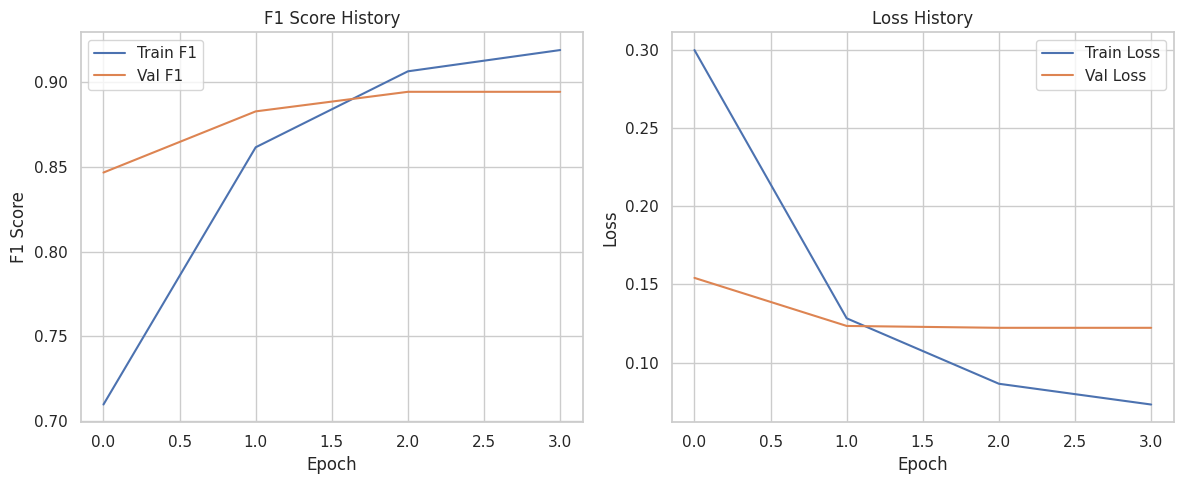

In [48]:
custom_trainer.history_plot()

In [49]:
df=custom_trainer.get_sample_losses_as_dataframe(tokenizer)

In [50]:
df

,text,labels,preds,loss
0,İSTİQAMƏTLƏNDİRMƏ İslam Əməkdaşlıq Təşkilatı,"[-100, 0, -100, -100, -100, -100, -100, -100, ...","[5, 5, 2, 5, 2, 2, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...",2.273292
1,Türkiyə ilə sərhədin uzunluğu 50 km-ə yaxındır .,"[-100, 5, 0, 0, -100, 0, 0, 0, -100, -100, 0, ...","[5, 5, 5, 5, 6, 5, 5, 2, 2, 5, 5, 5, 5, 5, 5, ...",1.844299
2,' '' Nəriman Nərimanov '' ',"[-100, 0, 0, 1, 2, -100, 0, 0, -100, -100, -10...","[3, 5, 5, 5, 2, 5, 5, 5, 5, 3, 4, 5, 1, 2, 4, ...",2.019800
3,Komanda hal-hazırda Acıbadem Qadınlararası Vol...,"[-100, 0, -100, 0, -100, -100, 3, -100, -100, ...","[5, 5, 5, 5, 5, 2, 5, 5, 1, 5, 2, 5, 5, 5, 5, ...",2.216483
4,Repertuarına Azərbaycan və xarici ölkə bəstəka...,"[-100, 0, -100, -100, -100, 5, 0, 0, 0, 0, -10...","[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...",1.875854
...,...,...,...,...
39995,С. И. Юткевич ; Редкол .,"[-100, 1, -100, 2, -100, 2, -100, -100, 0, 0, ...","[2, 1, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, ...",0.005010
39996,Yeniçərilər II Mehmedin dövründə daha da güclə...,"[-100, 3, -100, -100, -100, 1, 2, -100, -100, ...","[2, 3, 0, 0, 0, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, ...",0.096337
39997,İSTİQAMƏTLƏNDİRMƏ Kembric Hersoginyası Ketrin,"[-100, 0, -100, -100, -100, -100, -100, -100, ...","[2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 2, 2, 2, ...",0.085746
39998,' '' Sofo Nijaradze '' ',"[-100, 0, 0, 1, -100, 2, -100, -100, 0, 0, -10...","[2, 0, 0, 1, 1, 2, 2, 2, 0, 0, 2, 2, 2, 1, 2, ...",0.021076


## Error analysis

In [ ]:
#plot true confusion matrix and etc

Səhv analizi üçün hesablanır:   0%|          | 0/63 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `XLMRobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


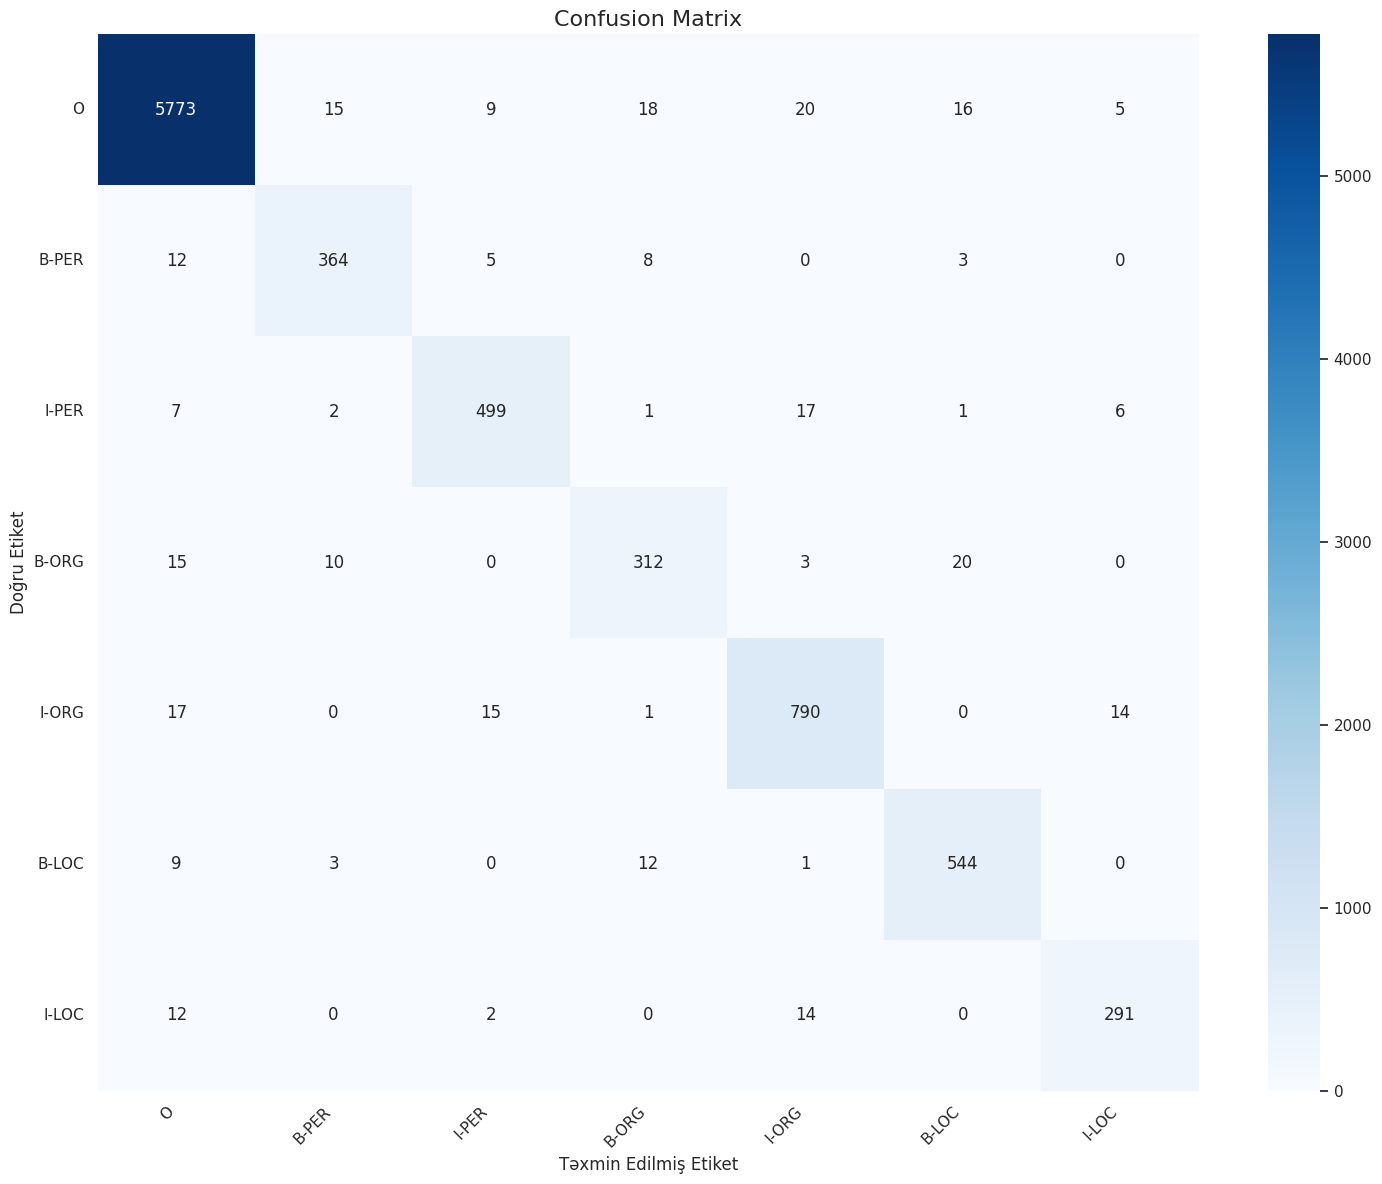

In [65]:
model, optimizer, train_dataloader, eval_dataloader, lr_scheduler = accelerator.prepare(
    model, optimizer, train_dataloader, eval_dataloader, lr_scheduler
)

errors=analyze_and_show_errors(
    model=model,
    dataloader=eval_dataloader,
    accelerator=accelerator,
    label_list=label_names,
    tokenizer=tokenizer
)

In [67]:
pd.DataFrame(errors)

,text,tokens,true_labels,predicted_labels,full_true_sequence,full_predicted_sequence
0,Çao Çao özü Syuyçana qaçır .,"[▁Ça, o, ▁Ça, o, ▁özü, ▁Sy, u, y, ça, na, ▁qaç...","[B-PER, B-PER]","[B-PER, I-PER, B-LOC]","[B-PER, B-PER, O, O, O, O]","[B-PER, I-PER, O, B-LOC, O, O]"
1,Bizans İmperatorluğu isə bu hücumlara müqavimə...,"[▁Biz, ans, ▁İm, per, ator, luğu, ▁isə, ▁bu, ▁...","[B-LOC, I-LOC]","[B-ORG, I-ORG]","[B-LOC, I-LOC, O, O, O, O, O, O, O]","[B-ORG, I-ORG, O, O, O, O, O, O, O]"
2,"Olçüsünə görə Kukunor , Nam-So , Lanqa-So , Ba...","[▁Ol, ç, üsü, nə, ▁görə, ▁Ku, ku, nor, ▁, ,, ▁...",[B-LOC],"[B-LOC, B-LOC, B-LOC, B-LOC, B-LOC]","[O, O, B-LOC, O, O, O, O, O, O, O, O, O, O, O, O]","[O, O, B-LOC, O, B-LOC, O, B-LOC, O, B-LOC, O,..."
3,Xəritədə Vikinqlərin Şimali Amerikada kəşf etd...,"[▁X, əri, t, ədə, ▁Vi, kin, q, lərin, ▁Şimali,...","[B-ORG, B-LOC, I-LOC]","[B-LOC, I-LOC]","[O, B-ORG, B-LOC, I-LOC, O, O, O, O, O, O]","[O, O, B-LOC, I-LOC, O, O, O, O, O, O]"
4,Üçüncü dəfə Mərdanşahın anası Şirin ilə .,"[▁Üçüncü, ▁dəfə, ▁Mə, r, dan, şa, h, ın, ▁an, ...",[B-PER],"[B-LOC, B-PER]","[O, O, O, O, B-PER, O, O]","[O, O, B-LOC, O, B-PER, O, O]"
...,...,...,...,...,...,...
151,' '' I Səlim '' ',"[▁', ▁'', ▁I, ▁Sə, lim, ▁'', ▁']","[B-PER, I-PER, I-PER, I-PER, I-PER, B-PER]","[B-PER, I-PER]","[B-PER, I-PER, I-PER, I-PER, I-PER, B-PER]","[O, O, B-PER, I-PER, O, O]"
152,I Pyotrun heykəli yerləşən Konnetabl meydanın ...,"[▁I, ▁Py, ot, run, ▁hey, k, əli, ▁yerləşən, ▁K...","[B-PER, I-PER]","[B-PER, I-PER, B-ORG, I-ORG]","[B-PER, I-PER, O, O, O, O, O, O, O, O, O, O, O...","[B-PER, I-PER, O, O, B-ORG, I-ORG, O, O, O, O,..."
153,Səfəvi şahı tərəfindən göndərilən və qırılması...,"[▁Sə, fə, vi, ▁şah, ı, ▁tərəfindən, ▁göndər, i...","[B-ORG, I-ORG]","[B-PER, I-PER]","[B-ORG, I-ORG, O, O, O, O, O, O, O, O, O, O, O...","[B-PER, I-PER, O, O, O, O, O, O, O, O, O, O, O..."
154,Müqəddəs Roma imperiyası ; Avstriya imperiyası,"[▁Mü, qə, d, də, s, ▁Roma, ▁imperi, yası, ▁;, ...","[B-ORG, I-ORG, I-ORG, B-LOC, I-LOC]","[B-ORG, I-ORG, I-ORG, B-ORG, I-ORG]","[B-ORG, I-ORG, I-ORG, O, B-LOC, I-LOC]","[B-ORG, I-ORG, I-ORG, O, B-ORG, I-ORG]"


## Results